In [28]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.set_option('display.max_columns', None)


In [15]:
chile_data = pd.read_csv('data/proc/test_final_kz.csv')
chile_data.head()

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,HAPAG-LLOYD,HMM,MAERSK,MSC,ONE,OOCL,OTHERS,PIL,SEALAND,WAN HAI,YANG MING,ZIM,CANTIDAD DE BULTO,TIPO DE BULTO,ALEMANIA,CHINA,COLOMBIA,ESPANA,FRANCIA,INDIA,ITALIA,MEXICO,ORIGEN O DESTINO NO PRECISADO,OTHER_COUNTRIES,PERU,U.S.A,VIETNAM,FE,IND,NAE,NAW,NE,SAE,SAW,SE,MEAN_DIFF_DAYS,MAX_DIFF_DAYS,STD_DIFF_DAYS,MEAN_FOB_POR_BULTO,MAX_FOB_POR_BULTO,STD_FOB_POR_BULTO,MEAN_SEGURO_POR_BULTO,MAX_SEGURO_POR_BULTO,STD_SEGURO_POR_BULTO,MEAN_FLETE_POR_BULTO,MAX_FLETE_POR_BULTO,STD_FLETE_POR_BULTO,MEAN_PESO BRUTO POR CONTENEDOR,MAX_PESO BRUTO POR CONTENEDOR,STD_PESO BRUTO POR CONTENEDOR,MEAN_ITEMS POR CONTENEDOR,MAX_ITEMS POR CONTENEDOR,STD_ITEMS POR CONTENEDOR,wan_hai_price,wan_hai_volume,wan_hai_pct_change,data_gold_price,data_gold_volume,data_gold_pct_change,zim_price,zim_volume,zim_pct_change,sea_price,sea_volume,sea_pct_change,ipsa_price,ipsa_volume,ipsa_pct_change,cny_price,cny_volume,cny_pct_change,clp_price,clp_volume,clp_pct_change,wti_oil_price,wti_oil_volume,wti_oil_pct_change,csi300_price,csi300_volume,csi300_pct_change,brent_oil_price,brent_oil_volume,brent_oil_pct_change,maersk_price,maersk_volume,maersk_pct_change,hapag_price,hapag_volume,hapag_pct_change,yang_ming_price,yang_ming_volume,yang_ming_pct_change,cosco_shipping_price,cosco_shipping_volume,cosco_shipping_pct_change,boat_price,boat_volume,boat_pct_change,sp500_price,sp500_volume,sp500_pct_change,XSICFEUW Index (R4),XSICFENE Index (R1),XSICFESE Index (L4),XSICNEFE Index (R2),XSICNESE Index (L2),XSICUENE Index (R1),XSICUWFE Index (L1),XSICNEUE Index (L3),BDIY Index (R3),Close_pct_change_XSICFEUW Index (R4),Close_pct_change_XSICFENE Index (R1),Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3)
0,2020-30,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,6568.500000,3700.621667,3684.795357,1390.591667,898.500000,4957.473684,16.250000,1258.817500,651.800000,1518.0,527.134423,71745.282000,261458.810,107032.191364,1082.960000,5229.180,2317.921973,2990.050000,7712.000,3384.466079,9064.800000,12322.0,4266.684099,0.900000,1.0,0.223607,13.754940,8208672.0,-0.005714,1962.800049,242791.0,0.034523,12.05,7824600.0,0.0,19.414,13200.0,0.0,5058.879883,0.0,0.0,7.0073,0.0,0.000600,761.000000,0.0,-0.011560,40.270000,1756486.0,-0.024703,5146.379883,390600.0,0.0,43.299999,83260.0,-0.000923,8076.0,87860.0,-0.037426,46.400002,120145.0,-0.050153,6.31,9683547.0,0.009600,2.246153,101068929.0,0.081481,25.155001,15400.0,0.0,3271.120117,2.177414e+10,0.017256,2681.0,1593.0,650.0,1437.0,1060.0,537.0,654.0,1925.0,1350.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2020-31,5.0,10.0,0.0,37.0,1.0,0.0,5.0,0.0,2.0,6.0,0.0,7.0,4.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,8.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,6250.000000,3487.292083,4097.397679,1286.810000,4630.636364,5410.552632,2064.911765,650.000000,473.812500,1154.0,355.272584,17797.612969,76500.000,13644.447436,209.662969,335.000,128.508849,3139.915937,10649.920,3465.751919,23526.296875,102000.0,31804.837504,3.843750,6.0,2.005788,14.466403,13892966.0,0.051724,2010.099976,5217.0,0.024098,12.05,7824600.0,0.0,19.414,13200.0,0.0,5058.879883,0.0,0.0,6.9524,0.0,-0.007835,773.000000,0.0,0.015769,41.220001,2039776.0,0.023591,5146.379883,390600.0,0.0,44.400002,127019.0,0.025404,8750.0,96177.0,0.083457,47.349998,141658.0,0.020474,6.46,11750692.0,0.023772,2.523076,186265371.0,0.123288,25.155001,15400.0,0.0,3351.280029,2.177734e+10,0.024505,3097.0,1645.0,1189.0,1405.0,1040.0,479.0,633.0,1895.0,1501.0,0.155166,0.032643,0.829231,-0.022269,-0.018868,-0.108007,-0.032110,-0.015584,0.111852
2,2020-32,7.0,7.0,1.0,42.0,0.0,0.0,0.0,4.0,0.0,

In [19]:
folder_path = "data/uruguay/"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_19083/338981070.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_19083/338981070.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_19083/338981070.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_19083/338981070.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in all_files]
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_19083/338981070.py:3: Dt

In [21]:
df['FECHA'] = df['DIA'].apply(lambda x: str(x)) + '-' + df['MES'].apply(lambda x: str(x)) + '-' + df['AÑO'].apply(lambda x: str(x))
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d-%m-%Y')
df.sort_values('FECHA', inplace=True)
df

,DIA,MES,AÑO,NUM DE ACEPTACION,TIPO DE OPERACION,ADUANA,IMPORTADOR,RUT,DV RUT,VIA DE TRANSPORTE,COMPAñIA DE TRANSPORTE,INCOTERMS,NUM DE ITEM,PARTIDA ARANCELARIA,DESCRIPCION ARANCELARIA,MERCANCIA,PAIS DE ORIGEN,PAIS DE ADQUISICION,PAIS DE PROCEDENCIA,CANTIDAD COMERCIAL,UNIDAD COMERCIAL,CANTIDAD ESTADISTICA,UNIDAD ESTADISTICA,US$ FOB ITEM,US$ FLETE ITEM,US$ SEGURO ITEM,US$ CIF ITEM,US$ FOB UNIT,CANTIDAD UNITARIA,PESO NETO ITEM,NOMBRE DESPACHANTE,CODIGO DE PAGO 1,PORCENTAJE DE PAGO 1,VALOR PAGADO 1,CODIGO DE PAGO 2,PORCENTAJE DE PAGO 2,VALOR PAGADO 2,CODIGO PAGADO 3,PORCENTAJE DE PAGO 3,VALOR PAGADO 3,CODIGO DE PAGO 4,PORCENTAJE DE PAGO 4,VALOR PAGADO 4,CODIGO DE PAGO 5,PORCENTAJE DE PAGO 5,VALOR PAGADO 5,PESO BRUTO TOTAL,FECHA
2783240,2,1,2018,201800100000425,Importacion Defenitiva con Despacho desde Depo...,Montevideo,SEINE S A,21236293001,1,Marítima,NaN,XXX,10,3924100000,VAJILLA Y DEMAS ARTICULOS PARA EL SERVICIO DE ...,ARTICULOS PLASTICOS - 340.78 MILLARES - ITEM 4...,Colombia,Colombia,Colombia,340.78,Un Millar,2.19,Toneladas,8215.24,0.00,0.00,8215.24,24.11,340.78,2194.91,LIGUORI DENDI ENZO GUSTAVO,Impuesto Aduanero Unico a la Importacion,0.0,67088.0,Impuesto Valor Agregado,2200.0,184491.0,Recargo Adicional,0.0,33544.0,Recargo Minimo,0.0,50316.0,Impuesto Valor Agregado Adicional,1000.0,83860.0,21180.22,2018-01-02
2783459,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,61,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,11.00,Unidad (C/U),0.01,Toneladas,247.77,0.00,0.00,247.77,22.52,11.00,9.58,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,1491.0,Impuesto Valor Agregado,2200.0,6012.0,Recargo Adicional,400.0,994.0,Recargo Minimo,600.0,1491.0,Impuesto Valor Agregado Adicional,1000.0,2733.0,7637.38,2018-01-02
2783460,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,62,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,1.00,Unidad (C/U),0.00,Toneladas,31.02,0.00,0.00,31.02,31.02,1.00,1.18,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,187.0,Impuesto Valor Agregado,2200.0,753.0,Recargo Adicional,400.0,124.0,Recargo Minimo,600.0,187.0,Impuesto Valor Agregado Adicional,1000.0,342.0,7637.38,2018-01-02
2783461,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,63,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULA DE RETENCION,Estados Unidos,Mexico,Mexico,22.00,Unidad (C/U),0.04,Toneladas,959.96,0.00,0.00,959.96,43.63,22.00,36.46,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,5776.0,Impuesto Valor Agregado,2200.0,23295.0,Recargo Adicional,400.0,3850.0,Recargo Minimo,600.0,5776.0,Impuesto Valor Agregado Adicional,1000.0,10589.0,7637.38,2018-01-02
2783462,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,64,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULAS .-,Estados Unidos,Mexico,Mexico,16.00,Unidad (C/U),0.05,Toneladas,437.40,0.00,0.00,437.40,27.34,16.00,51.32,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,2631.0,Impuesto Valor Agregado,2200.0,10610.0,Recargo Adicional,400.0,1754.0,Recargo Minimo,600.0,2631.0,Impuesto Valor Agregado Adicional,1000.0,4823.0,7637.38,2018-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222830,31,8,2024,2024001100325905,Importacion Definitiva con Despacho desde Depo...,Montevideo,MAESTROS CAFETEROS SRL,21455169001,4,Maritima,NaN,FOB,2,2106909000,LAS DEMAS. LAS DEMAS. PREPARACIONES ALIMENTIC

In [22]:
df.columns

Index(['DIA', 'MES', 'AÑO', 'NUM DE ACEPTACION', 'TIPO DE OPERACION', 'ADUANA',
       'IMPORTADOR', 'RUT', 'DV RUT', 'VIA DE TRANSPORTE',
       'COMPAñIA DE TRANSPORTE', 'INCOTERMS', 'NUM DE ITEM',
       'PARTIDA ARANCELARIA', 'DESCRIPCION ARANCELARIA', 'MERCANCIA',
       'PAIS DE ORIGEN', 'PAIS DE ADQUISICION', 'PAIS DE PROCEDENCIA',
       'CANTIDAD COMERCIAL', 'UNIDAD COMERCIAL', 'CANTIDAD ESTADISTICA',
       'UNIDAD ESTADISTICA', 'US$ FOB ITEM', 'US$ FLETE ITEM',
       'US$ SEGURO ITEM', 'US$ CIF ITEM', 'US$ FOB UNIT', 'CANTIDAD UNITARIA',
       'PESO NETO ITEM', 'NOMBRE DESPACHANTE', 'CODIGO DE PAGO 1',
       'PORCENTAJE DE PAGO 1', 'VALOR PAGADO 1', 'CODIGO DE PAGO 2',
       'PORCENTAJE DE PAGO 2', 'VALOR PAGADO 2', 'CODIGO PAGADO 3',
       'PORCENTAJE DE PAGO 3', 'VALOR PAGADO 3', 'CODIGO DE PAGO 4',
       'PORCENTAJE DE PAGO 4', 'VALOR PAGADO 4', 'CODIGO DE PAGO 5',
       'PORCENTAJE DE PAGO 5', 'VALOR PAGADO 5', 'PESO BRUTO TOTAL', 'FECHA'],
      dtype='object')

In [33]:
df.head(1)

,DIA,MES,AÑO,NUM DE ACEPTACION,TIPO DE OPERACION,ADUANA,IMPORTADOR,RUT,DV RUT,VIA DE TRANSPORTE,COMPAñIA DE TRANSPORTE,INCOTERMS,NUM DE ITEM,PARTIDA ARANCELARIA,DESCRIPCION ARANCELARIA,MERCANCIA,PAIS DE ORIGEN,PAIS DE ADQUISICION,PAIS DE PROCEDENCIA,CANTIDAD COMERCIAL,UNIDAD COMERCIAL,CANTIDAD ESTADISTICA,UNIDAD ESTADISTICA,US$ FOB ITEM,US$ FLETE ITEM,US$ SEGURO ITEM,US$ CIF ITEM,US$ FOB UNIT,CANTIDAD UNITARIA,PESO NETO ITEM,NOMBRE DESPACHANTE,CODIGO DE PAGO 1,PORCENTAJE DE PAGO 1,VALOR PAGADO 1,CODIGO DE PAGO 2,PORCENTAJE DE PAGO 2,VALOR PAGADO 2,CODIGO PAGADO 3,PORCENTAJE DE PAGO 3,VALOR PAGADO 3,CODIGO DE PAGO 4,PORCENTAJE DE PAGO 4,VALOR PAGADO 4,CODIGO DE PAGO 5,PORCENTAJE DE PAGO 5,VALOR PAGADO 5,PESO BRUTO TOTAL,FECHA
2783240,2,1,2018,201800100000425,Importacion Defenitiva con Despacho desde Depo...,Montevideo,SEINE S A,21236293001,1,Marítima,NaN,XXX,10,3924100000,VAJILLA Y DEMAS ARTICULOS PARA EL SERVICIO DE ...,ARTICULOS PLASTICOS - 340.78 MILLARES - ITEM 4...,Colombia,Colombia,Colombia,340.78,Un Millar,2.19,Toneladas,8215.24,0.0,0.0,8215.24,24.11,340.78,2194.91,LIGUORI DENDI ENZO GUSTAVO,Impuesto Aduanero Unico a la Importacion,0.0,67088.0,Impuesto Valor Agregado,2200.0,184491.0,Recargo Adicional,0.0,33544.0,Recargo Minimo,0.0,50316.0,Impuesto Valor Agregado Adicional,1000.0,83860.0,21180.22,2018-01-02


In [32]:
df.sort_values('PESO BRUTO TOTAL', ascending=False).head(10)

,DIA,MES,AÑO,NUM DE ACEPTACION,TIPO DE OPERACION,ADUANA,IMPORTADOR,RUT,DV RUT,VIA DE TRANSPORTE,COMPAñIA DE TRANSPORTE,INCOTERMS,NUM DE ITEM,PARTIDA ARANCELARIA,DESCRIPCION ARANCELARIA,MERCANCIA,PAIS DE ORIGEN,PAIS DE ADQUISICION,PAIS DE PROCEDENCIA,CANTIDAD COMERCIAL,UNIDAD COMERCIAL,CANTIDAD ESTADISTICA,UNIDAD ESTADISTICA,US$ FOB ITEM,US$ FLETE ITEM,US$ SEGURO ITEM,US$ CIF ITEM,US$ FOB UNIT,CANTIDAD UNITARIA,PESO NETO ITEM,NOMBRE DESPACHANTE,CODIGO DE PAGO 1,PORCENTAJE DE PAGO 1,VALOR PAGADO 1,CODIGO DE PAGO 2,PORCENTAJE DE PAGO 2,VALOR PAGADO 2,CODIGO PAGADO 3,PORCENTAJE DE PAGO 3,VALOR PAGADO 3,CODIGO DE PAGO 4,PORCENTAJE DE PAGO 4,VALOR PAGADO 4,CODIGO DE PAGO 5,PORCENTAJE DE PAGO 5,VALOR PAGADO 5,PESO BRUTO TOTAL,FECHA
1229085,8,1,2020,202000100002461,Importacion Definitiva con Despacho Directo,Montevideo,ADMINISTRACION NACIONAL DE COMBUSTIBLES ALCOHO...,21047573001,1,Marítima,NaN,DAP,1,2713110000,"SIN CALCINAR. SIN CALCINAR. COQUE DE PETROLEO,...","COQUE DE PETROLEO 32.999,87 TONELADAS",Colombia,Suiza,Suiza,32203.12,Toneladas,32203.12,Toneladas,2736587.87,0.00,28049.88,2764637.75,84.98,32203.12,32203120.0,ADMINISTRACION NACIONAL DE COMBUSTIBLES.A.LCOH...,Impuesto Valor Agregado,2200.0,65497119.0,Impuesto Valor Agregado Adicional,1000.0,29771419.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,65202992.0,2020-01-08
409130,31,7,2019,201900100129267,Importacion Definitiva con Despacho Directo,Montevideo,ADMINISTRACION NACIONAL DE COMBUSTIBLES ALCOHO...,21047573001,1,Marítima,NaN,XXX,1,2713110000,SIN CALCINAR. COQUE DE PETROLEO. SIN CALCINAR....,"COQUE DE PETROLEO 31.772,00 TONELADAS",Estados Unidos,Estados Unidos,Estados Unidos,31772.00,Toneladas,31772.00,Toneladas,2160496.00,0.00,0.00,2160496.00,68.00,31772.00,31772000.0,ADMINISTRACION NACIONAL DE COMBUSTIBLES.A.LCOH...,Impuesto Valor Agregado,2200.0,50417312.0,Impuesto Valor Agregado Adicional,1000.0,22916959.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,63544000.0,2019-07-31
353871,11,6,2019,201900100097704,Importacion Definitiva con Despacho Directo,Montevideo,ADMINISTRACION NACIONAL DE COMBUSTIBLES ALCOHO...,21047573001,1,Marítima,NaN,XXX,1,2520101100,EN TROZOS IRREGULARES (PIEDRAS). YESO NATURAL;...,YESO MINERAL 30.80 TONELADAS METRICAS,Espana,Estados Unidos,Estados Unidos,30800.00,Toneladas,30925.73,Toneladas,1079351.67,0.00,10749.20,1090100.87,35.04,30800.00,30925730.0,ADMINISTRACION NACIONAL DE COMBUSTIBLES.A.LCOH...,Impuesto Valor Agregado,2200.0,27263138.0,Recargo Minimo,400.0,4766283.0,Impuesto Valor Agregado Adicional,1000.0,12392335.0,NaN,0.0,0.0,NaN,0.0,0.0,61725728.0,2019-06-11
421197,9,8,2019,201900100135733,Importacion Definitiva con Despacho Directo,Montevideo,COMPAAæIA INDUSTRIALIZADORA DE MINERALES SA,21490773001,1,Marítima,NaN,XXX,1,2523299000,LOS DEMAS. CEMENTO PORTLAND. LOS DEMAS. CEMENT...,"CEMENTO PORTLAND - 30.718,50 TONELADAS",Turquia,Malta,Malta,30718.50,Toneladas,30718.50,Toneladas,2138007.50,0.00,4269.00,2142276.50,69.60,30718.50,30718500.0,GOBERTTI SANCHEZ HECTOR DANIEL,Impuesto Valor Agregado,2200.0,53372894.0,Recargo Minimo,400.0,9330925.0,Impuesto Valor Agregado Adicional,1000.0,24260406.0,NaN,0.0,0.0,NaN,0.0,0.0,61559872.0,2019-08-09
2613351,25,4,2019,201900100067287,Importacion Definitiva con Despacho Directo,Montevideo,COMPAAæIA INDUSTRIALIZADORA DE MINERALES SA,21490773001,1,Marítima,NaN,XXX,1,2523299000,LOS DEMAS. CEMENTO PORTLAND. LOS DEMAS. CEMENT...,CEMENTO PORTLAND - 30.657 TONELADAS,Turquia,Malta,Malta,30657.00,Toneladas,30657.00,Toneladas,2133727.25,0.00,4260.00,2137987.25,69.60,30657.00,30657000.0,GOBERTTI SANCHEZ HECTOR DANIEL,Impuesto Valor Agregado,2200.0,53302838.0,Recargo Minimo,400.0,9318678.0,Impuesto Valor Agregado Adicional,1000.0,24228562.0,NaN,0.0,0.0,NaN,0.0,0.0,61436628.0,2019-04-25
2034989,15,6,2020,202000100087209,Importacion Definitiva con Despacho Directo,Montevideo,COMPANIA INDUSTRIALIZADORA DE MINERALES SA,21490773001,1,Marítima,NaN,CFR,1,2523291000,CEMENTO NORMAL. LOS DEMAS. CEMENTOS HIDRAULICO...,"CEMENTO PORTLAND - 26.599,5

(0.0, 112880.0)

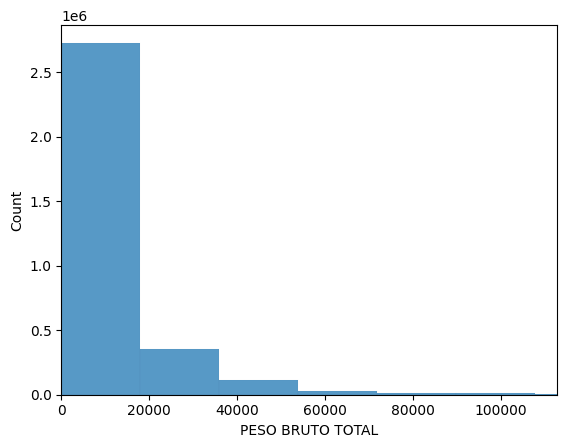

In [30]:
sns.histplot(df['PESO BRUTO TOTAL'])
plt.xlim(0, df['PESO BRUTO TOTAL'].quantile(0.99))


Text(0, 0.5, 'Average Cost per Container (US$)')

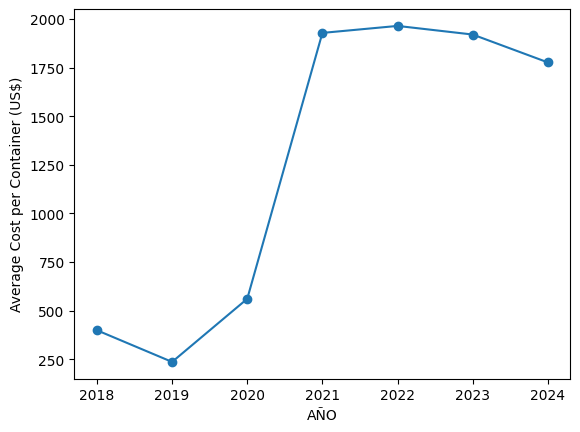

In [40]:
min_container_threshold = 0.1
df['estimated_containers'] = df['PESO BRUTO TOTAL'].apply(lambda x: max(x / 17000, min_container_threshold))
df['cost_per_container'] = df['US$ FLETE ITEM'] / df['estimated_containers']
df.groupby('AÑO')['cost_per_container'].mean().plot(marker='o')
plt.ylabel('Average Cost per Container (US$)')

In [42]:
df['COMPAñIA DE TRANSPORTE'].unique()

array([nan])

In [45]:
df['PAIS DE ORIGEN'].unique()

array(['Colombia', 'Estados Unidos', 'República Popular de China',
       'Panama', 'Paises Bajos', 'Malasia', 'Camboya', 'Suiza',
       'República de Corea del Sur', 'Sudafrica', 'Peru', 'Bélgica',
       'Brasil', 'Vietnam', 'Lituania', 'Honduras', 'Finlandia',
       'Estonia', 'Espana', 'Zona Franca Florida', 'Uruguay',
       'Zona Franca Montevideo', 'Zona Franca Libertad',
       'Zona Franca Colonia', 'Japon', 'Taiwán', 'Canadá',
       'ZONA FRANCA PARQUE DE LAS CIENCIAS SA', 'Paraguay', 'India',
       'Alemania', 'Suecia', 'Grecia', 'Tailandia', 'Turquia',
       'Indonesia', 'Portugal', 'Francia', 'Italia', 'Israel',
       'Reino Unido', 'Arabia Saudita', 'Mexico', 'Republica Dominica',
       'Polonia', 'Pakistan', 'Hong Kong', 'Ecuador', 'Bulgaria',
       'Austria', 'Dinamarca', 'Irlanda',
       'República Democrática Popular de Corea Norte', 'Chile',
       'Argentina', 'Sri Lanka', 'Egipto', 'República Checa',
       'Federacion Rusia', 'Singapur', 'Rumania', 'Filip

In [ ]:
countries = [
    'Colombia', 'Estados Unidos', 'República Popular de China',
    'Panama', 'Paises Bajos', 'Malasia', 'Camboya', 'Suiza',
    'República de Corea del Sur', 'Sudafrica', 'Peru', 'Bélgica',
    'Brasil', 'Vietnam', 'Lituania', 'Honduras', 'Finlandia',
    'Estonia', 'Espana', 'Zona Franca Florida', 'Uruguay',
    'Zona Franca Montevideo', 'Zona Franca Libertad',
    'Zona Franca Colonia', 'Japon', 'Taiwán', 'Canadá',
    'ZONA FRANCA PARQUE DE LAS CIENCIAS SA', 'Paraguay', 'India',
    'Alemania', 'Suecia', 'Grecia', 'Tailandia', 'Turquia',
    'Indonesia', 'Portugal', 'Francia', 'Italia', 'Israel',
    'Reino Unido', 'Arabia Saudita', 'Mexico', 'Republica Dominica',
    'Polonia', 'Pakistan', 'Hong Kong', 'Ecuador', 'Bulgaria',
    'Austria', 'Dinamarca', 'Irlanda',
    'República Democrática Popular de Corea Norte', 'Chile',
    'Argentina', 'Sri Lanka', 'Egipto', 'República Checa',
    'Federacion Rusia', 'Singapur', 'Rumania', 'Filipinas',
    'Australia', 'Noruega', 'Letonia', 'Tunez', 'Nueva Zelandia',
    'Emiratos Arabes Unidos (E.A.U)',
    'Zonas Franca Manaos (Según Decreto)', 'El Salvador', 'Moldavia',
    'Guatemala', 'Zon Franca Frey Bentos - Botnia', 'Sudan',
    'Eslovenia', 'Ghana', 'Cuba', 'Jamaica',
    'Islas Vírgenes Británicas', 'Bangladesh', 'Costa Rica', 'Belice',
    'Bolivia', 'Namibia', 'Birmania', 'Islas Malvinas', 'Qatar',
    'Yugoslavia', 'Liberia', 'Oman', 'Pesca Alta Mar', 'Marruecos',
    'Malta', 'Senegal', 'Republica Eslovaquia', 'Venezuela', 'Nigeria',
    'Hungria', 'Iran', 'Z.F. AGUADA PARK', 'Liechtenstein', 'Armenia',
    'Zona del Canal de Panama', 'Uzbekistan', 'Metropolitana Francia',
    'Afganistán', 'Z.F. PUNTA PEREIRA', 'Macao', 'Croacia', 'Gabón',
    'Georgia', 'Bosnia y Herzegovina', 'Barbados', 'Guyana',
    'Jordania', 'Chipre', 'Islas Bahrein', 'Islas Cook', 'Ucrania',
    'Albania', 'Puerto Rico', 'Mozambique', 'Luxemburgo', 'Libano',
    'Vanuatu', 'Costa Marfil', 'Libia', 'Samoa Americana',
    'Madagascar', 'Areas Aduaneras Especiales de Argentina',
    'Trinidad y Tobago', 'Nueva Caledonia', 'Islas Maldivas',
    'Argelia', 'Mauricio', 'Republica Seychelles',
    'Islas Heard and Mc Donald', 'Zona Franca Rivera', 'Gibraltar',
    'República del Congo', 'Zona Nueva Helvecia', 'Islas Comoras',
    'Bielorrusia', 'Samoa', 'Republica Unida de Tanzania',
    'Turkmenistan', 'Dominica', 'Kenia', 'Kazajstán', 'Serbia',
    'Malawi', 'Z.F. WORLD TRADE CENTER',
    'Posesión Estadounidense Insular', 'Nicaragua', 'Granada',
    'Cabo Verde', 'Sahara Occidental', 'Antártida\n', 'Martinique',
    'Montenegro', None, 'Zona Franca Durazno', 'Zona Franca San Jose',
    'Haiti', 'Camerún', 'Belgica', 'Islas Bahamas', 'Macedonia',
    'Afganistan', 'Niger', 'Etiopía', 'San Marino', 'Islandia',
    'Rwanda', 'Tokelau', 'Isla Svalbard and Jan Mayen',
    'San Cristobal y Nevis', 'Uganda', 'Nepal', 'Somalia',
    'República Popular Democrática de Laos', 'Bermudas',
    'Islas Navidad', 'Brunei Darussalam', 'Isla Niue', 'Monaco',
    'Sierra Leona', 'Sudán', 'Andorra', 'Mongolia',
    'Antigua y Barbuda', 'Zambia', 'Gambia', 'Groenlandia', 'Togo',
    'Leshoto', 'Zimbabwe', 'San Vicente y Las Granadinas',
    'Timor Oriental', 'Republica Arabe Siria', 'Kuwait', 'Mauritania',
    'Kirguistan', 'Estado de Palestina', 'Isla Santa Lucia',
    'Burkina Faso', 'Tuvalu', 'Burundi', 'Djibuti', 'Isla Pitcairn',
    'Islas Caimán', 'Islas Cocos (Keeling)', 'Isla Reunion',
    'Azerbaiján', 'Iraq', '248', 'Anguilla', 'Guinea',
    'Isla Marianas del Norte', 'Republica Popular de China',
    'Republica Checa', 'Taiwan', 'Canada',
    'Republica de Corea del Sur', 'Camerun',
    'Republica Popular Democratica de Laos', 'Republica del Congo',
    'Etiopia', 'Suriname', 'Nauru', 'Kazajstan', 'Gabon', 'Butan',
    'Curaçao', 'Republica Central Africana',
    'Republica Democratica Popular de Corea Norte'
]

america = {
    'Colombia', 'Estados Unidos', 'Panama', 'Peru', 'Brasil', 'Honduras',
    'Zona Franca Florida', 'Uruguay', 'Zona Franca Montevideo',
    'Zona Franca Libertad', 'Zona Franca Colonia', 'Canadá',
    'ZONA FRANCA PARQUE DE LAS CIENCIAS SA', 'Paraguay', 'Mexico',
    'Republica Dominica', 'Ecuador', 'Chile', 'Argentina',
    'Zonas Franca Manaos (Según Decreto)', 'El Salvador', 'Guatemala',
    'Zon Franca Frey Bentos - Botnia', 'Cuba', 'Jamaica',
    'Islas Vírgenes Británicas', 'Costa Rica', 'Belice', 'Bolivia',
    'Islas Malvinas', 'Zona del Canal de Panama', 'Barbados', 'Guyana',
    'Puerto Rico', 'Areas Aduaneras Especiales de Argentina',
    'Trinidad y Tobago', 'Zona Franca Rivera', 'Zona Nueva Helvecia',
    'Dominica', 'Z.F. WORLD TRADE CENTER',
    'Posesión Estadounidense Insular', 'Nicaragua', 'Granada',
    'Martinique', 'Zona Franca Durazno', 'Zona Franca San Jose',
    'Haiti', 'Islas Bahamas', 'Bermudas', 'Antigua y Barbuda',
    'Groenlandia', 'San Cristobal y Nevis',
    'San Vicente y Las Granadinas', 'Isla Santa Lucia',
    'Islas Caimán', 'Anguilla', 'Suriname', 'Curaçao', 'Venezuela',
    'Canada'
}

far_east = {
    'República Popular de China', 'Republica Popular de China', 'Japon',
    'Taiwán', 'Taiwan', 'Hong Kong', 'Macao',
    'República de Corea del Sur', 'Republica de Corea del Sur',
    'República Democrática Popular de Corea Norte',
    'Republica Democratica Popular de Corea Norte',
    'República Popular Democrática de Laos',
    'Republica Popular Democratica de Laos', 'Vietnam', 'Camboya',
    'Malasia', 'Tailandia', 'Indonesia', 'Singapur', 'Filipinas',
    'Birmania', 'Brunei Darussalam', 'Timor Oriental', 'Mongolia',
    'Butan'
}

northern_europe = {
    'Paises Bajos', 'Suiza', 'Finlandia', 'Estonia', 'Lituania',
    'Letonia', 'Suecia', 'Noruega', 'Alemania', 'Bélgica', 'Belgica',
    'Francia', 'Metropolitana Francia', 'Reino Unido', 'Irlanda',
    'Polonia', 'Austria', 'Dinamarca', 'Luxemburgo', 'Liechtenstein',
    'Bielorrusia', 'Federacion Rusia', 'Ucrania',
    'Republica Checa', 'República Checa', 'Republica Eslovaquia',
    'Hungria', 'Islandia', 'Isla Svalbard and Jan Mayen', 'Moldavia'
}

southern_europe = {
    'Espana', 'Portugal', 'Grecia', 'Italia', 'Malta', 'Chipre',
    'Croacia', 'Bosnia y Herzegovina', 'Serbia', 'Montenegro',
    'Albania', 'Macedonia', 'Eslovenia', 'Bulgaria', 'Rumania',
    'San Marino', 'Andorra', 'Monaco', 'Gibraltar'
}

middle_east = {
    'Israel', 'Arabia Saudita', 'Egipto',
    'Emiratos Arabes Unidos (E.A.U)', 'Qatar', 'Oman', 'Kuwait',
    'Iran', 'Iraq', 'Jordania', 'Libano', 'Islas Bahrein',
    'Republica Arabe Siria', 'Estado de Palestina', 'Turquia'
}

india = {'India'}

countries_by_region = {
    "America": [],
    "Far East": [],
    "Northern Europe": [],
    "Southern Europe": [],
    "Middle East": [],
    "India": [],
    "Others": [],
}

for c in countries:
    # skip non-string entries like None
    if not isinstance(c, str):
        continue

    if c in america:
        countries_by_region["America"].append(c)
    elif c in far_east:
        countries_by_region["Far East"].append(c)
    elif c in northern_europe:
        countries_by_region["Northern Europe"].append(c)
    elif c in southern_europe:
        countries_by_region["Southern Europe"].append(c)
    elif c in middle_east:
        countries_by_region["Middle East"].append(c)
    elif c in india:
        countries_by_region["India"].append(c)
    else:
        countries_by_region["Others"].append(c)

country_to_region = {}

for region, clist in countries_by_region.items():
    for c in clist:
        country_to_region[c] = region


In [49]:
df['region'] = df['PAIS DE ORIGEN'].map(country_to_region).fillna('Others')
df

,DIA,MES,AÑO,NUM DE ACEPTACION,TIPO DE OPERACION,ADUANA,IMPORTADOR,RUT,DV RUT,VIA DE TRANSPORTE,COMPAñIA DE TRANSPORTE,INCOTERMS,NUM DE ITEM,PARTIDA ARANCELARIA,DESCRIPCION ARANCELARIA,MERCANCIA,PAIS DE ORIGEN,PAIS DE ADQUISICION,PAIS DE PROCEDENCIA,CANTIDAD COMERCIAL,UNIDAD COMERCIAL,CANTIDAD ESTADISTICA,UNIDAD ESTADISTICA,US$ FOB ITEM,US$ FLETE ITEM,US$ SEGURO ITEM,US$ CIF ITEM,US$ FOB UNIT,CANTIDAD UNITARIA,PESO NETO ITEM,NOMBRE DESPACHANTE,CODIGO DE PAGO 1,PORCENTAJE DE PAGO 1,VALOR PAGADO 1,CODIGO DE PAGO 2,PORCENTAJE DE PAGO 2,VALOR PAGADO 2,CODIGO PAGADO 3,PORCENTAJE DE PAGO 3,VALOR PAGADO 3,CODIGO DE PAGO 4,PORCENTAJE DE PAGO 4,VALOR PAGADO 4,CODIGO DE PAGO 5,PORCENTAJE DE PAGO 5,VALOR PAGADO 5,PESO BRUTO TOTAL,FECHA,cost_per_container,estimated_containers,region
2783240,2,1,2018,201800100000425,Importacion Defenitiva con Despacho desde Depo...,Montevideo,SEINE S A,21236293001,1,Marítima,NaN,XXX,10,3924100000,VAJILLA Y DEMAS ARTICULOS PARA EL SERVICIO DE ...,ARTICULOS PLASTICOS - 340.78 MILLARES - ITEM 4...,Colombia,Colombia,Colombia,340.78,Un Millar,2.19,Toneladas,8215.24,0.00,0.00,8215.24,24.11,340.78,2194.91,LIGUORI DENDI ENZO GUSTAVO,Impuesto Aduanero Unico a la Importacion,0.0,67088.0,Impuesto Valor Agregado,2200.0,184491.0,Recargo Adicional,0.0,33544.0,Recargo Minimo,0.0,50316.0,Impuesto Valor Agregado Adicional,1000.0,83860.0,21180.22,2018-01-02,0.000000,1.245895,America
2783459,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,61,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,11.00,Unidad (C/U),0.01,Toneladas,247.77,0.00,0.00,247.77,22.52,11.00,9.58,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,1491.0,Impuesto Valor Agregado,2200.0,6012.0,Recargo Adicional,400.0,994.0,Recargo Minimo,600.0,1491.0,Impuesto Valor Agregado Adicional,1000.0,2733.0,7637.38,2018-01-02,0.000000,0.449258,America
2783460,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,62,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,1.00,Unidad (C/U),0.00,Toneladas,31.02,0.00,0.00,31.02,31.02,1.00,1.18,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,187.0,Impuesto Valor Agregado,2200.0,753.0,Recargo Adicional,400.0,124.0,Recargo Minimo,600.0,187.0,Impuesto Valor Agregado Adicional,1000.0,342.0,7637.38,2018-01-02,0.000000,0.449258,America
2783461,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,63,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULA DE RETENCION,Estados Unidos,Mexico,Mexico,22.00,Unidad (C/U),0.04,Toneladas,959.96,0.00,0.00,959.96,43.63,22.00,36.46,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,5776.0,Impuesto Valor Agregado,2200.0,23295.0,Recargo Adicional,400.0,3850.0,Recargo Minimo,600.0,5776.0,Impuesto Valor Agregado Adicional,1000.0,10589.0,7637.38,2018-01-02,0.000000,0.449258,America
2783462,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,64,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULAS .-,Estados Unidos,Mexico,Mexico,16.00,Unidad (C/U),0.05,Toneladas,437.40,0.00,0.00,437.40,27.34,16.00,51.32,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,2631.0,Impuesto Valor Agregado,2200.0,10610.0,Recargo Adicional,400.0,1754.0,Recargo Minimo,600.0,2631.0,Impuesto Valor Agregado Adicional,1000.0,4823.0,7637.38,2018-01-02,0.000000,0.449258,America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222830,31,8,2024,2

In [58]:
df.INCOTERMS.value_counts()

INCOTERMS
FOB    2248456
XXX     753913
CIF     121339
DAP      58282
EXW      36216
FCA      28429
CFR      26391
CPT       6520
CIP       4664
DAT       1706
DDP        453
FAS         99
Name: count, dtype: int64

In [52]:
df.to_csv('data/uruguay/uruguay_shipping_data.csv', index=False)

In [54]:
df.region.value_counts()

region
Far East           1578727
America             584379
Northern Europe     469356
Southern Europe     304676
Middle East         208485
India                80737
Others               60521
Name: count, dtype: int64

In [55]:
df.columns

Index(['DIA', 'MES', 'AÑO', 'NUM DE ACEPTACION', 'TIPO DE OPERACION', 'ADUANA',
       'IMPORTADOR', 'RUT', 'DV RUT', 'VIA DE TRANSPORTE',
       'COMPAñIA DE TRANSPORTE', 'INCOTERMS', 'NUM DE ITEM',
       'PARTIDA ARANCELARIA', 'DESCRIPCION ARANCELARIA', 'MERCANCIA',
       'PAIS DE ORIGEN', 'PAIS DE ADQUISICION', 'PAIS DE PROCEDENCIA',
       'CANTIDAD COMERCIAL', 'UNIDAD COMERCIAL', 'CANTIDAD ESTADISTICA',
       'UNIDAD ESTADISTICA', 'US$ FOB ITEM', 'US$ FLETE ITEM',
       'US$ SEGURO ITEM', 'US$ CIF ITEM', 'US$ FOB UNIT', 'CANTIDAD UNITARIA',
       'PESO NETO ITEM', 'NOMBRE DESPACHANTE', 'CODIGO DE PAGO 1',
       'PORCENTAJE DE PAGO 1', 'VALOR PAGADO 1', 'CODIGO DE PAGO 2',
       'PORCENTAJE DE PAGO 2', 'VALOR PAGADO 2', 'CODIGO PAGADO 3',
       'PORCENTAJE DE PAGO 3', 'VALOR PAGADO 3', 'CODIGO DE PAGO 4',
       'PORCENTAJE DE PAGO 4', 'VALOR PAGADO 4', 'CODIGO DE PAGO 5',
       'PORCENTAJE DE PAGO 5', 'VALOR PAGADO 5', 'PESO BRUTO TOTAL', 'FECHA',
       'cost_per_contain

In [ ]:
# number of companies per week
# mean max std containers, flete, all dollar values
# cost_per_container is per region

In [60]:
import pandas as pd

# Make sure FECHA is datetime, just in case
df['FECHA'] = pd.to_datetime(df['FECHA'])

# Week starting on Monday; adjust 'W-MON' to 'W-SUN' if you prefer
df['week'] = df['FECHA'].dt.to_period('W-MON').dt.start_time
df

,DIA,MES,AÑO,NUM DE ACEPTACION,TIPO DE OPERACION,ADUANA,IMPORTADOR,RUT,DV RUT,VIA DE TRANSPORTE,COMPAñIA DE TRANSPORTE,INCOTERMS,NUM DE ITEM,PARTIDA ARANCELARIA,DESCRIPCION ARANCELARIA,MERCANCIA,PAIS DE ORIGEN,PAIS DE ADQUISICION,PAIS DE PROCEDENCIA,CANTIDAD COMERCIAL,UNIDAD COMERCIAL,CANTIDAD ESTADISTICA,UNIDAD ESTADISTICA,US$ FOB ITEM,US$ FLETE ITEM,US$ SEGURO ITEM,US$ CIF ITEM,US$ FOB UNIT,CANTIDAD UNITARIA,PESO NETO ITEM,NOMBRE DESPACHANTE,CODIGO DE PAGO 1,PORCENTAJE DE PAGO 1,VALOR PAGADO 1,CODIGO DE PAGO 2,PORCENTAJE DE PAGO 2,VALOR PAGADO 2,CODIGO PAGADO 3,PORCENTAJE DE PAGO 3,VALOR PAGADO 3,CODIGO DE PAGO 4,PORCENTAJE DE PAGO 4,VALOR PAGADO 4,CODIGO DE PAGO 5,PORCENTAJE DE PAGO 5,VALOR PAGADO 5,PESO BRUTO TOTAL,FECHA,cost_per_container,estimated_containers,region,week
2783240,2,1,2018,201800100000425,Importacion Defenitiva con Despacho desde Depo...,Montevideo,SEINE S A,21236293001,1,Marítima,NaN,XXX,10,3924100000,VAJILLA Y DEMAS ARTICULOS PARA EL SERVICIO DE ...,ARTICULOS PLASTICOS - 340.78 MILLARES - ITEM 4...,Colombia,Colombia,Colombia,340.78,Un Millar,2.19,Toneladas,8215.24,0.00,0.00,8215.24,24.11,340.78,2194.91,LIGUORI DENDI ENZO GUSTAVO,Impuesto Aduanero Unico a la Importacion,0.0,67088.0,Impuesto Valor Agregado,2200.0,184491.0,Recargo Adicional,0.0,33544.0,Recargo Minimo,0.0,50316.0,Impuesto Valor Agregado Adicional,1000.0,83860.0,21180.22,2018-01-02,0.000000,1.245895,America,2018-01-02
2783459,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,61,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,11.00,Unidad (C/U),0.01,Toneladas,247.77,0.00,0.00,247.77,22.52,11.00,9.58,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,1491.0,Impuesto Valor Agregado,2200.0,6012.0,Recargo Adicional,400.0,994.0,Recargo Minimo,600.0,1491.0,Impuesto Valor Agregado Adicional,1000.0,2733.0,7637.38,2018-01-02,0.000000,0.449258,America,2018-01-02
2783460,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,62,8302300000,"LAS DEMAS GUARNICIONES, HERRAJES Y ARTICULOS S...",CILINDRO DE GAS,Estados Unidos,Mexico,Mexico,1.00,Unidad (C/U),0.00,Toneladas,31.02,0.00,0.00,31.02,31.02,1.00,1.18,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,187.0,Impuesto Valor Agregado,2200.0,753.0,Recargo Adicional,400.0,124.0,Recargo Minimo,600.0,187.0,Impuesto Valor Agregado Adicional,1000.0,342.0,7637.38,2018-01-02,0.000000,0.449258,America,2018-01-02
2783461,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,63,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULA DE RETENCION,Estados Unidos,Mexico,Mexico,22.00,Unidad (C/U),0.04,Toneladas,959.96,0.00,0.00,959.96,43.63,22.00,36.46,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,5776.0,Impuesto Valor Agregado,2200.0,23295.0,Recargo Adicional,400.0,3850.0,Recargo Minimo,600.0,5776.0,Impuesto Valor Agregado Adicional,1000.0,10589.0,7637.38,2018-01-02,0.000000,0.449258,America,2018-01-02
2783462,2,1,2018,201800100000563,Importacion Defenitiva con Despacho desde Depo...,Montevideo,INTERAGROVIAL S A,21006543001,8,Marítima,NaN,XXX,64,8409991410,DESTINADOS A VEHICULOS AUTOMOTORES. LAS DEMAS....,VALVULAS .-,Estados Unidos,Mexico,Mexico,16.00,Unidad (C/U),0.05,Toneladas,437.40,0.00,0.00,437.40,27.34,16.00,51.32,JAUME Y SERE LIMITADA,Impuesto Aduanero Unico a la Importacion,0.0,2631.0,Impuesto Valor Agregado,2200.0,10610.0,Recargo Adicional,400.0,1754.0,Recargo Minimo,600.0,2631.0,Impuesto Valor Agregado Adicional,1000.0,4823.0,7637.38,2018-01-02,0.000000,0.449258,America,2018-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [62]:
weekly_companies = (
    df.groupby('week')['IMPORTADOR']
      .nunique()
      .rename('n_companies')
)
weekly_companies

week
2018-01-02     862
2018-01-09     899
2018-01-16     904
2018-01-23     927
2018-01-30     856
              ... 
2024-07-30    1047
2024-08-06     949
2024-08-13     882
2024-08-20     809
2024-08-27     960
Name: n_companies, Length: 348, dtype: int64

In [65]:
# columns that contain 'US$' or 'VALOR PAGADO' in their name
dollar_cols = [
    col for col in df.columns
    if 'US$' in col
]

num_cols = ['estimated_containers', 'cost_per_container'] + dollar_cols
num_cols

['estimated_containers',
 'cost_per_container',
 'US$ FOB ITEM',
 'US$ FLETE ITEM',
 'US$ SEGURO ITEM',
 'US$ CIF ITEM',
 'US$ FOB UNIT']

In [67]:
agg_funcs = {col: ['mean', 'max', 'std'] for col in num_cols}

weekly_stats = df.groupby('week').agg(agg_funcs)
weekly_stats.columns = [
    f"{col[0]}_{col[1]}" for col in weekly_stats.columns
]


In [68]:
weekly_summary = weekly_stats.join(weekly_companies)

# Optional: move n_companies to the front
cols = ['n_companies'] + [c for c in weekly_summary.columns if c != 'n_companies']
weekly_summary = weekly_summary[cols]


In [80]:
weekly_sum = weekly_summary.reset_index()
weekly_sum

,week,n_companies,estimated_containers_mean,estimated_containers_max,estimated_containers_std,cost_per_container_mean,cost_per_container_max,cost_per_container_std,US$ FOB ITEM_mean,US$ FOB ITEM_max,US$ FOB ITEM_std,US$ FLETE ITEM_mean,US$ FLETE ITEM_max,US$ FLETE ITEM_std,US$ SEGURO ITEM_mean,US$ SEGURO ITEM_max,US$ SEGURO ITEM_std,US$ CIF ITEM_mean,US$ CIF ITEM_max,US$ CIF ITEM_std,US$ FOB UNIT_mean,US$ FOB UNIT_max,US$ FOB UNIT_std
0,2018-01-02,862,0.631456,80.986000,1.653554,586.914659,296885.600000,3945.874007,11257.574133,1557608.00,46293.142043,240.103388,29688.56,1061.695957,25.501493,3105.00,118.471790,11523.179014,1557608.00,46529.863053,1059.269679,751500.00,13737.446542
1,2018-01-09,899,0.517833,88.442941,1.681423,409.289130,45710.000000,1505.383522,7292.631087,2425000.00,40037.155404,149.851186,21600.00,652.635482,16.147685,2872.11,73.640386,7458.629958,2425000.00,40216.463116,4222.886589,15999999.24,235204.796517
2,2018-01-16,904,0.810792,1473.035882,16.595442,428.687322,37722.500000,1601.771201,9014.096164,4255669.00,77928.052483,158.827063,30570.83,724.406947,18.217443,3422.11,75.185565,9191.140671,4255669.00,78030.750218,660.317599,300406.33,7123.354613
3,2018-01-23,927,0.644158,129.465882,3.182030,545.277659,30061.080262,1754.938792,10879.363710,4372374.00,70068.357024,211.980245,52457.93,1180.959754,21.160961,7692.30,120.233293,11112.504916,4372374.00,70303.939109,1999.773937,4372374.00,52201.077979
4,2018-01-30,856,0.963945,377.057059,8.535936,558.591030,41384.987469,1800.990367,11479.095326,3193784.75,64030.825085,233.298313,194827.91,2476.198941,24.457660,6117.76,130.770417,11736.851299,3193784.75,64421.017400,779.963162,268682.66,6994.053359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2024-07-30,1047,0.858876,928.332706,11.293219,1792.446925,282836.653386,5877.867330,10955.957950,12204248.92,132232.650677,1095.595720,1220424.89,13223.265061,109.559573,122042.49,1322.326524,12161.113242,13546716.30,146778.242262,0.000000,0.00,0.000000
344,2024-08-06,949,0.871340,834.958176,10.231856,1714.781696,949427.700000,10040.203826,9283.635813,12663219.32,123282.968325,928.363508,1266321.93,12328.296816,92.836320,126632.19,1232.829658,10304.835641,14056173.44,136844.094799,0.000000,0.00,0.000000
345,2024-08-13,882,0.962593,302.475588,6.277025,2191.746210,240202.900436,8031.983432,11589.587832,10634159.25,122469.901004,1158.958755,1063415.93,12246.990136,115.895872,106341.59,1224.698976,12864.442459,11803916.77,135941.590115,0.000000,0.00,0.000000
346,2024-08-20,809,0.850084,294.117647,6.214761,1847.746581,87820.972089,5102.153699,10719.425692,4839344.10,80785.806419,1071.942474,483934.41,8078.580628,107.194324,48393.44,807.858023,11898.562489,5371671.95,89672.245070,0.000000,0.00,0.000000


In [71]:
weekly_region_cost = (
    df.groupby(['week', 'region'])['cost_per_container']
      .agg(['mean', 'max', 'std'])
      .reset_index()
)
weekly_region_cost

,week,region,mean,max,std
0,2018-01-02,America,405.848092,296885.600000,6793.842061
1,2018-01-02,Far East,1051.489050,29951.000000,2587.247279
2,2018-01-02,India,507.499743,12210.014948,1303.342952
3,2018-01-02,Middle East,376.197163,13038.572335,1871.349120
4,2018-01-02,Northern Europe,210.172566,36192.164675,1238.610933
...,...,...,...,...,...
2430,2024-08-27,India,1557.619714,14578.036508,3019.258517
2431,2024-08-27,Middle East,971.285076,15051.768599,1861.587507
2432,2024-08-27,Northern Europe,2162.269214,64935.900000,6358.787034
2433,2024-08-27,Others,1337.051774,24603.834119,3065.733262


In [79]:
weekly_region_cost_pivot = (
    weekly_region_cost
    .pivot(index='week', columns='region', values='mean')  # or 'max' / 'std'
)
region_data = weekly_region_cost_pivot.reset_index()
region_data.columns = [col + "_container_cost" for col in region_data.columns]
region_data = region_data.rename(columns = {"week_container_cost":"week"})

In [81]:
final_df = pd.merge(weekly_sum, region_data, on='week', how='outer')
final_df

,week,n_companies,estimated_containers_mean,estimated_containers_max,estimated_containers_std,cost_per_container_mean,cost_per_container_max,cost_per_container_std,US$ FOB ITEM_mean,US$ FOB ITEM_max,US$ FOB ITEM_std,US$ FLETE ITEM_mean,US$ FLETE ITEM_max,US$ FLETE ITEM_std,US$ SEGURO ITEM_mean,US$ SEGURO ITEM_max,US$ SEGURO ITEM_std,US$ CIF ITEM_mean,US$ CIF ITEM_max,US$ CIF ITEM_std,US$ FOB UNIT_mean,US$ FOB UNIT_max,US$ FOB UNIT_std,America_container_cost,Far East_container_cost,India_container_cost,Middle East_container_cost,Northern Europe_container_cost,Others_container_cost,Southern Europe_container_cost
0,2018-01-02,862,0.631456,80.986000,1.653554,586.914659,296885.600000,3945.874007,11257.574133,1557608.00,46293.142043,240.103388,29688.56,1061.695957,25.501493,3105.00,118.471790,11523.179014,1557608.00,46529.863053,1059.269679,751500.00,13737.446542,405.848092,1051.489050,507.499743,376.197163,210.172566,1025.988505,261.337277
1,2018-01-09,899,0.517833,88.442941,1.681423,409.289130,45710.000000,1505.383522,7292.631087,2425000.00,40037.155404,149.851186,21600.00,652.635482,16.147685,2872.11,73.640386,7458.629958,2425000.00,40216.463116,4222.886589,15999999.24,235204.796517,159.817018,903.740636,636.455357,415.069093,146.234915,834.383231,370.688398
2,2018-01-16,904,0.810792,1473.035882,16.595442,428.687322,37722.500000,1601.771201,9014.096164,4255669.00,77928.052483,158.827063,30570.83,724.406947,18.217443,3422.11,75.185565,9191.140671,4255669.00,78030.750218,660.317599,300406.33,7123.354613,268.435123,674.158586,1154.217226,618.171337,153.083147,1148.480722,270.482753
3,2018-01-23,927,0.644158,129.465882,3.182030,545.277659,30061.080262,1754.938792,10879.363710,4372374.00,70068.357024,211.980245,52457.93,1180.959754,21.160961,7692.30,120.233293,11112.504916,4372374.00,70303.939109,1999.773937,4372374.00,52201.077979,249.475005,853.124544,313.118771,502.198186,448.028254,1106.080544,278.073334
4,2018-01-30,856,0.963945,377.057059,8.535936,558.591030,41384.987469,1800.990367,11479.095326,3193784.75,64030.825085,233.298313,194827.91,2476.198941,24.457660,6117.76,130.770417,11736.851299,3193784.75,64421.017400,779.963162,268682.66,6994.053359,218.791231,856.018981,1040.584720,934.809171,270.700658,2645.533406,316.875284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2024-07-30,1047,0.858876,928.332706,11.293219,1792.446925,282836.653386,5877.867330,10955.957950,12204248.92,132232.650677,1095.595720,1220424.89,13223.265061,109.559573,122042.49,1322.326524,12161.113242,13546716.30,146778.242262,0.000000,0.00,0.000000,2241.747370,1741.135612,2213.720582,678.833995,1718.167823,1133.250473,2006.402398
344,2024-08-06,949,0.871340,834.958176,10.231856,1714.781696,949427.700000,10040.203826,9283.635813,12663219.32,123282.968325,928.363508,1266321.93,12328.296816,92.836320,126632.19,1232.829658,10304.835641,14056173.44,136844.094799,0.000000,0.00,0.000000,3223.934274,1585.771307,1069.719385,567.733551,1847.034422,1327.405235,1935.716897
345,2024-08-13,882,0.962593,302.475588,6.277025,2191.746210,240202.900436,8031.983432,11589.587832,10634159.25,122469.901004,1158.958755,1063415.93,12246.990136,115.895872,106341.59,1224.698976,12864.442459,11803916.77,135941.590115,0.000000,0.00,0.000000,3361.725086,1915.059839,1222.705122,367.027028,3275.734687,1397.923479,3114.738667
346,2024-08-20,809,0.850084,294.117647,6.214761,1847.746581,87820.972089,5102.153699,10719.425692,4839344.10,80785.806419,1071.942474,483934.41,8078.580628,107.194324,48393.44,807.858023,11898.562489,5371671.95,89672.245070,0.000000,0.00,0.000000,3840.867547,1797.441145,1895.304091,498.469412,2162.242972,383.325828,2196.931344


In [82]:
final_df.to_csv('uruguay_weekly_kz.csv')